In [1]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

from util import *

In [2]:
models = list_models()
models

['proteus', 'pacman', 'moai', 'lincs', 'gooey', 'neongooey']

In [3]:
models_data = {}
for m in models:
    models_data[m] = load_model_data(m, quiet=True)

Loading model proteus
Loading model pacman
Loading model moai
Loading model lincs
Loading model gooey
Loading model neongooey


In [4]:
planets = list_planets()
planets

('earth', 'venus')

In [5]:
print(", ".join(models_data["proteus"]["earth"]["Hhigh-Chigh-evo"].keys()))

t(yr), T_surf(K), T_pot(K), flux_surf(W/m2), flux_OLR(W/m2), flux_ASR(W/m2), phi(vol_frac), fO2_melt(bar), fO2_solid(bar), thick_surf_bl(m), massC_solid(kg), massC_melt(kg), massC_atm(kg), massH_solid(kg), massH_melt(kg), massH_atm(kg), massO_atm(kg), p_surf(bar), p_H2O(bar), p_CO2(bar), p_CO(bar), p_H2(bar), p_CH4(bar), p_O2(bar), mmw(kg/mol), R_trans(m), R_solid(m), viscosity(Pa.s), phi(mass_frac), p_SO2(bar), p_NH3(bar), p_N2(bar), p_H2S(bar), p_S2(bar)


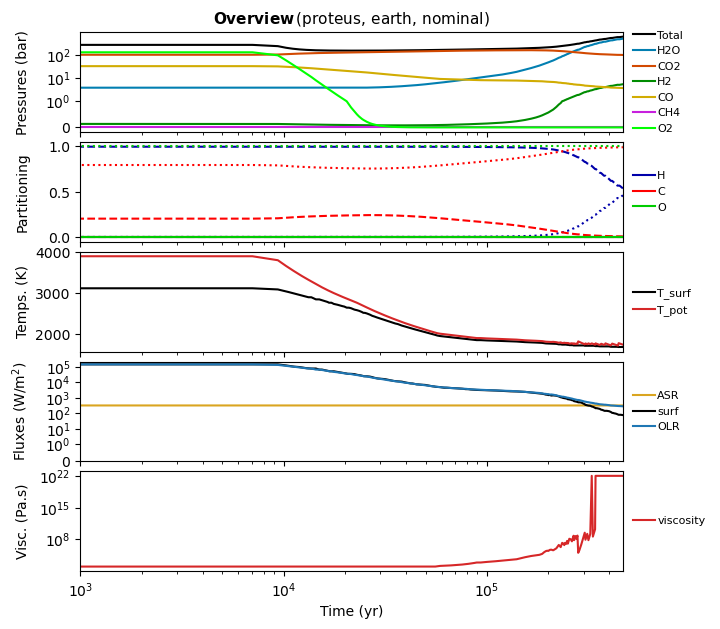

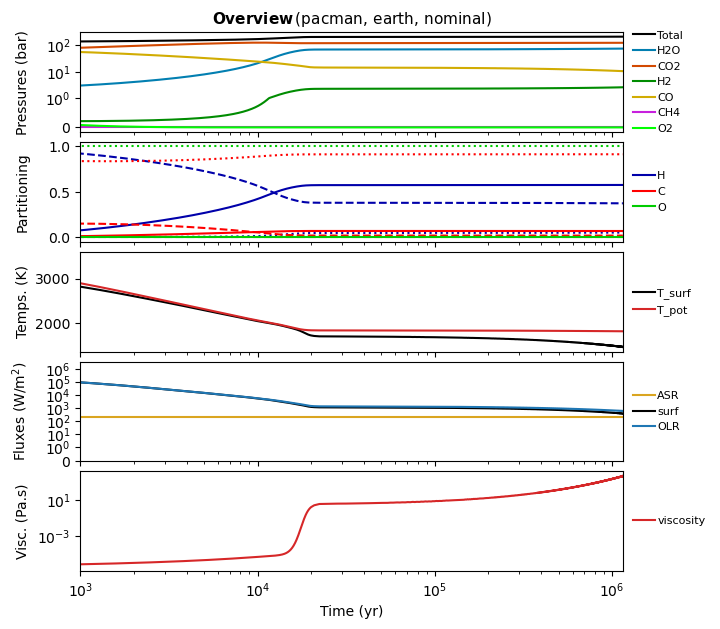

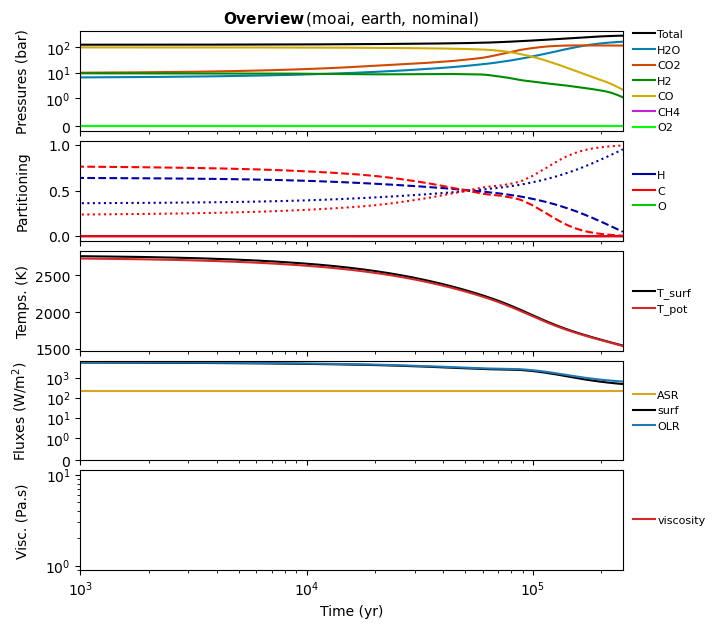

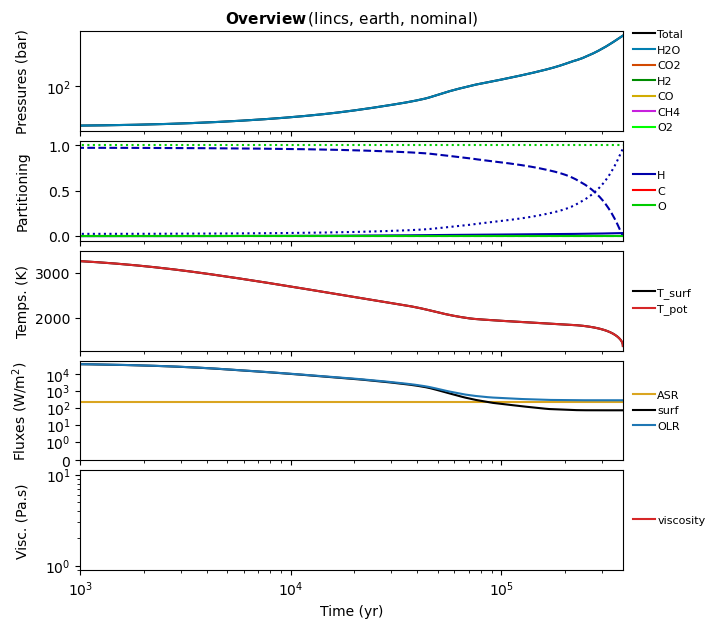

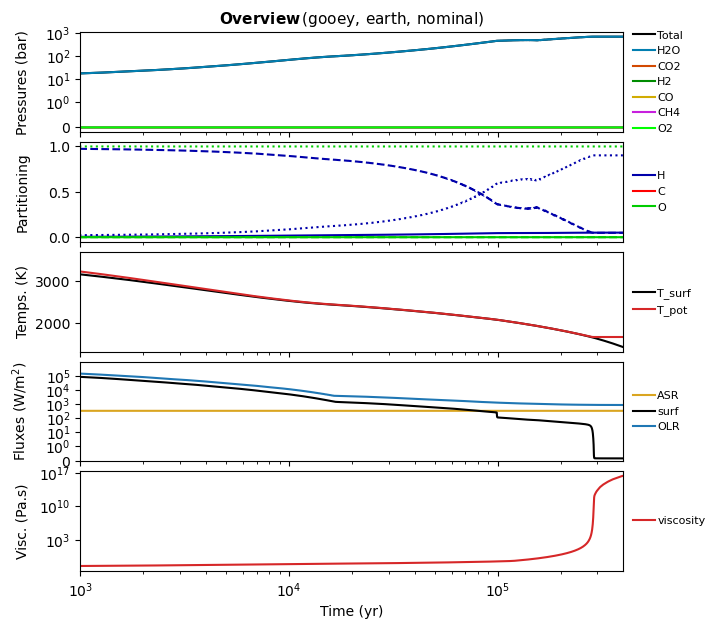

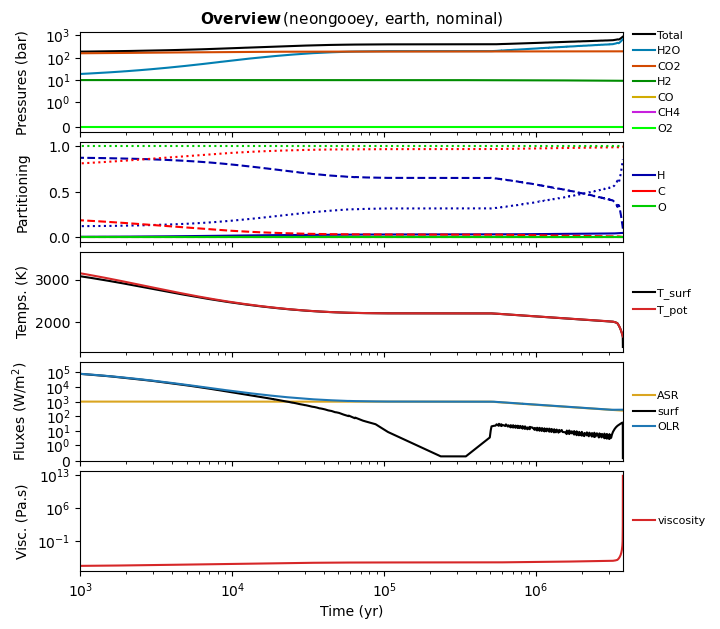

In [17]:
def plot_overview(model, planet, case):
    Nax = 5
    fig,axs = plt.subplots(Nax,1, figsize=(7,2+Nax), sharex=True)

    dat = models_data[model][planet][case+"-evo"]
    x = dat["t(yr)"]

    # Surface pressure
    ax = axs[0]
    ax.plot(x, dat["p_surf(bar)"], label="Total", color="k")
    for gas in chili_gases:
        ax.plot(x, dat[f"p_{gas}(bar)"], label=gas, color=get_color(gas))
    ax.set_yscale("symlog", linthresh=1)
    ax.set_ylabel("Pressures (bar)")

    # Partitioning
    for elem in ["H", "C", "O"]:
        ax = axs[1]
        ax.plot([],[], color=get_color(elem), ls='solid', label=f"{elem}")

        tot = np.zeros_like(x)
        for res in ["atm", "melt", "solid"]:
            key = f"mass{elem}_{res}(kg)"
            if key not in dat:
                dat[key] = np.zeros_like(x)
            tot += dat[key]

        for res in ["atm", "melt", "solid"]:
             key = f"mass{elem}_{res}(kg)"
             ax.plot(x, dat[key]/tot, color=get_color(elem), ls={'atm':'dotted', 'melt':'dashed', 'solid':'solid'}[res])
    ax.set_ylabel("Partitioning")

    # Temperatures
    ax = axs[2]
    ax.plot(x, dat["T_surf(K)"], c='black', label="T_surf")
    ax.plot(x, dat["T_pot(K)"],  c='tab:red', label="T_pot")
    ax.set_ylabel("Temps. (K)")

    # Fluxes
    ax = axs[3]
    ax.plot(x, dat["flux_ASR(W/m2)"],   c='goldenrod', label="ASR")
    ax.plot(x, dat["flux_surf(W/m2)"],  c='black', label="surf")
    ax.plot(x, dat["flux_OLR(W/m2)"],   c='tab:blue', label="OLR")
    ax.set_yscale("symlog", linthresh=1)
    ax.set_ylabel("Fluxes (W/m$^2$)")
    ax.set_ylim(bottom=0)

    # Viscosity
    ax = axs[4]
    ax.plot(x, dat["viscosity(Pa.s)"], c='tab:red', label="viscosity")
    ax.set_yscale("log")
    ax.set_ylabel("Visc. (Pa.s)")

    for ax in axs:
        ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8, handletextpad=0.2, columnspacing=0.9, frameon=False)
    axs[-1].set_xlabel("Time (yr)")
    axs[-1].set_xscale("log")
    axs[-1].set_xlim(left=1e3, right=np.amax(x))
    fig.subplots_adjust(hspace=0.1)

    title = r"${\bf Overview \,}({\rm " + model + r"},\,{\rm " + planet + r"},\,{\rm " + case + r"})$"
    axs[0].set_title(title, fontsize=11)

    fig.align_ylabels()

    plt.show()


for model in models:
    plot_overview(model, "earth", "nominal")